<a href="https://colab.research.google.com/github/AkashkannanB/Computer-vision/blob/main/optical%20flow%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files
uploaded = files.upload()

Saving car .mp4 to car .mp4


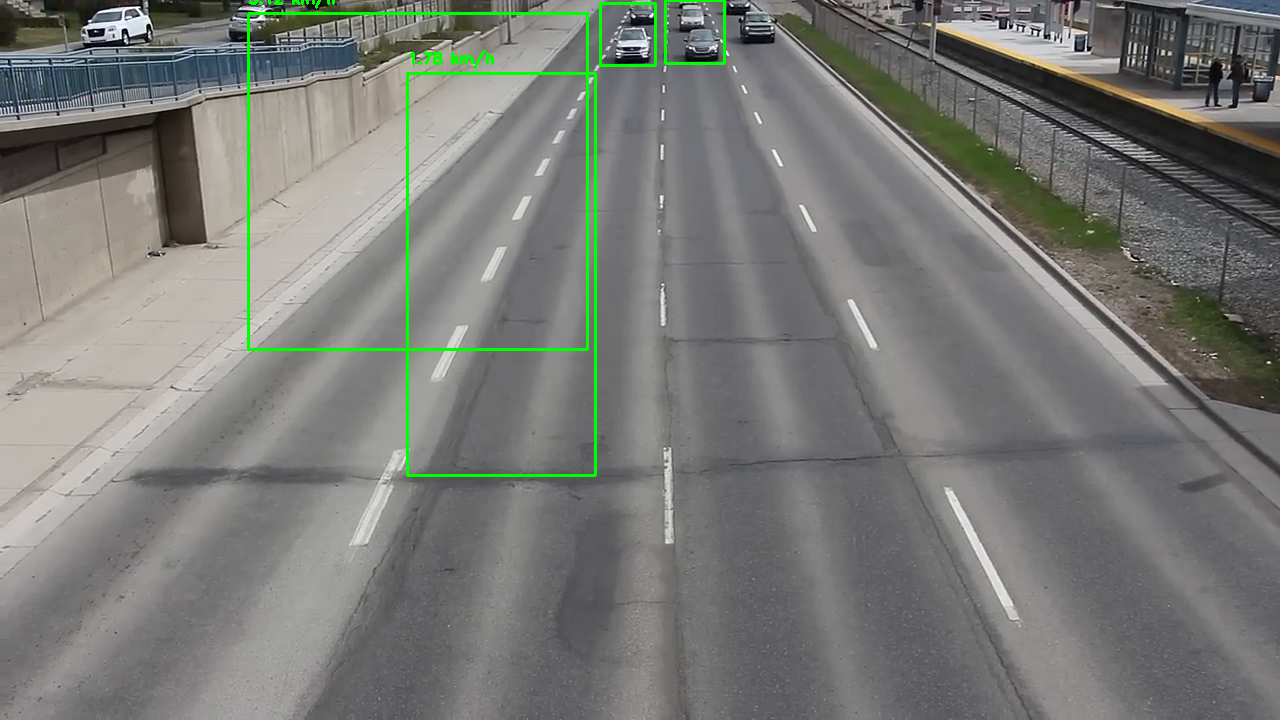

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import IPython.display

def calculate_speed(flow, scale_factor, fps):
    """
    Estimate speed in km/h from optical flow vectors.
    """
    magnitudes = np.sqrt(flow[..., 0] ** 2 + flow[..., 1] ** 2)  # Compute magnitude of flow vectors
    avg_magnitude = np.mean(magnitudes)  # Take average movement
    speed_m_per_s = avg_magnitude * scale_factor * fps  # Convert pixels/frame to m/s
    speed_km_per_h = speed_m_per_s * 3.6  # Convert m/s to km/h
    return speed_km_per_h

def detect_vehicles(frame, fg_mask):
    """
    Detect vehicles using background subtraction and contour filtering.
    """
    contours, _ = cv2.findContours(fg_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    vehicle_contours = []

    for contour in contours:
        if cv2.contourArea(contour) > 1000:  # Adjust threshold for vehicles
            x, y, w, h = cv2.boundingRect(contour)
            aspect_ratio = w / float(h)
            if 1.2 > aspect_ratio > 0.3:  # Filter out non-vehicle shapes
                vehicle_contours.append((x, y, w, h))

    return vehicle_contours

def draw_bounding_box(frame, vehicles, flow, scale_factor, fps):
    """
    Draw bounding boxes around detected vehicles and display their individual speeds.
    """
    for (x, y, w, h) in vehicles:
        roi_flow = flow[y:y+h, x:x+w]  # Extract flow for the detected vehicle
        speed = calculate_speed(roi_flow, scale_factor, fps)  # Compute individual vehicle speed

        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(frame, f"{speed:.2f} km/h", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

def main(video_path, scale_factor, fps):
    cap = cv2.VideoCapture(video_path)
    ret, prev_frame = cap.read()
    if not ret:
        print("Error: Unable to read video")
        return
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    background_subtractor = cv2.createBackgroundSubtractorMOG2()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Compute optical flow
        flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)

        # Apply background subtraction to detect moving objects
        fg_mask = background_subtractor.apply(gray)
        vehicles = detect_vehicles(frame, fg_mask)
        draw_bounding_box(frame, vehicles, flow, scale_factor, fps)

        # Display frame
        IPython.display.clear_output(wait=True) # Clear previous output to display new frame
        cv2_imshow(frame)

        # Update previous frame
        prev_gray = gray.copy()

    cap.release()
    IPython.display.clear_output(wait=True) # Clear the last frame after video finishes

if __name__ == "__main__":
    video_path = 'car .mp4'  # Replace with your video file
    scale_factor = 0.05  # Approximate meters per pixel (adjust as needed)
    fps = 30  # Frames per second of the video
    main(video_path, scale_factor, fps)
